# 01 · Raw EDA: HDB resale transactions
**Owner:** Pricing & Availability Lead · **Input:** `data/interim/resale_clean.csv` (run task *1b · Clean + validate* first)

The aim is **data understanding**: find what is in the data and what is odd about it, *before* modelling.
Every section ends with a **Finding** cell. Fill it in as you go; these become the report's data section.
Validation results are in `docs/validation_report.md`.

No coordinates are needed here. Location EDA lives in `02_processed_eda.ipynb` (after geocoding).

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
# Find src/ whether the kernel starts in the project root (VS Code setting) or in notebooks/
sys.path.insert(0, str(next(p / "src" for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "config.py").exists())))
import config as C

df = pd.read_csv(C.RESALE_CLEAN, dtype={"block": str})
ins = df[df["in_scope"]].copy()                      # 1-room, multi-generation, Terrace and partial month excluded
ins["year"] = ins["month"].str[:4].astype(int)
print(f"{len(df):,} rows · {len(ins):,} in scope · {df['month'].min()} to {df['month'].max()}")

# Chart style: fixed categorical order (validated palette), thin marks, recessive grid
TYPES = ["2 ROOM", "3 ROOM", "4 ROOM", "5 ROOM", "EXECUTIVE"]
COL = dict(zip(TYPES, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"]))
plt.rcParams.update({"figure.figsize": (10, 4.2), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8, "axes.axisbelow": True,
                     "axes.edgecolor": "#9a9a95", "axes.labelcolor": "#3d3d3a", "xtick.color": "#5c5c57",
                     "ytick.color": "#5c5c57", "lines.linewidth": 1.8, "legend.frameon": False, "font.size": 10})
def money(ax, axis="y"):
    fmt = plt.FuncFormatter(lambda v, _: f"${v/1e3:,.0f}k")
    (ax.yaxis if axis == "y" else ax.xaxis).set_major_formatter(fmt)
def band(s, bands):                                   # bands from config.py: [(lo, hi, label), ...], lo inclusive
    return pd.cut(s, [b[0] for b in bands] + [bands[-1][1]], labels=[b[2] for b in bands], right=False)

241,920 rows · 241,407 in scope · 2017-01 to 2026-10


## 1 · Volume over time
How many sales each month? Watch for the partial latest month and any COVID-period dip.

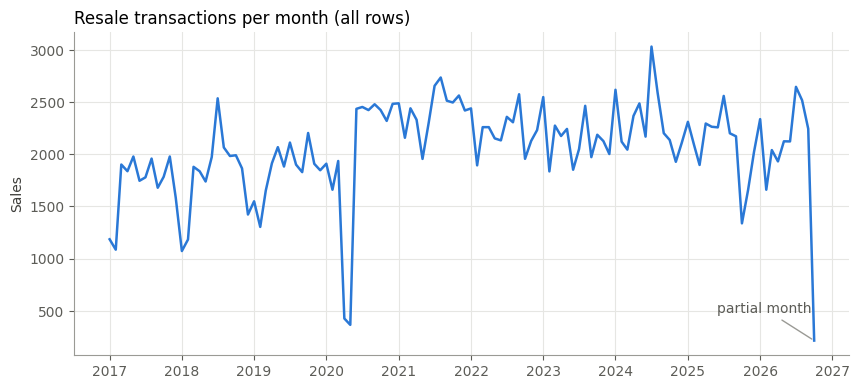

month
2017    20509
2018    21561
2019    22186
2020    23333
2021    29087
2022    26720
2023    25754
2024    27832
2025    25085
2026    19853
dtype: int64


In [2]:
vol = df.groupby("month").size()
fig, ax = plt.subplots()
ax.plot(pd.to_datetime(vol.index), vol.values, color="#2a78d6")
ax.set_title("Resale transactions per month (all rows)", loc="left"); ax.set_ylabel("Sales")
if df["partial_month"].any():
    ax.annotate("partial month", (pd.to_datetime(vol.index[-1]), vol.iloc[-1]), xytext=(-70, 20),
                textcoords="offset points", arrowprops={"arrowstyle": "-", "color": "#9a9a95"}, color="#5c5c57")
plt.show()
print(vol.groupby(vol.index.str[:4]).sum())

**Finding:** _e.g. volume range, dips, the partial month and how it is handled._

## 2 · Price trends by flat type
Monthly median price. This is *raw*, not quality-adjusted, so mix changes leak in. The hedonic index fixes that.

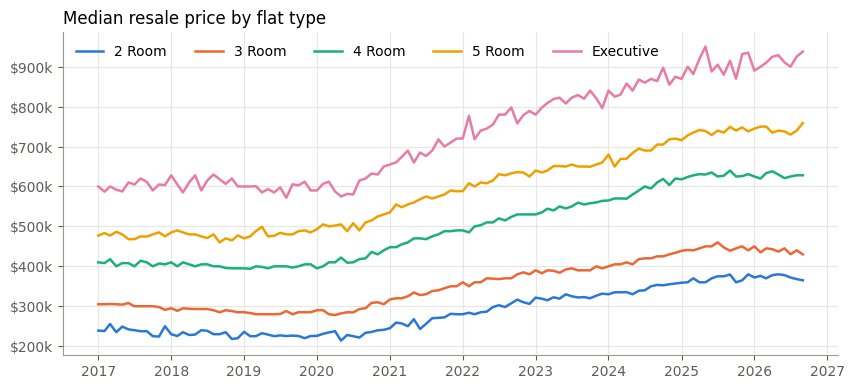

flat_type  2 ROOM  3 ROOM  4 ROOM  5 ROOM  EXECUTIVE
year                                                
2017          100     100     100     100        100
2018           96      96      98      99        102
2019           94      94      98     101         99
2020           96      98     103     106        103
2021          110     111     115     119        115
2022          125     123     126     130        127
2023          133     130     135     136        136
2024          142     139     145     144        143
2025          153     148     154     154        150
2026          155     146     154     155        152


In [3]:
fig, ax = plt.subplots()
for t in TYPES:
    s = ins[ins["flat_type"] == t].groupby("month")["resale_price"].median()
    ax.plot(pd.to_datetime(s.index), s.values, color=COL[t], label=t.title())
ax.set_title("Median resale price by flat type", loc="left"); money(ax); ax.legend(ncol=5, loc="upper left")
plt.show()
yr = ins.pivot_table(index="year", columns="flat_type", values="resale_price", aggfunc="median")[TYPES]
print((yr / yr.iloc[0] * 100).round(0).astype(int).to_string())   # index, 2017 = 100

**Finding:** _cumulative growth by flat type; when the acceleration started._

## 3 · Price per sqm distribution
Compares flats of different sizes. Flagged outliers are >5 robust SD from their flat type × year median.

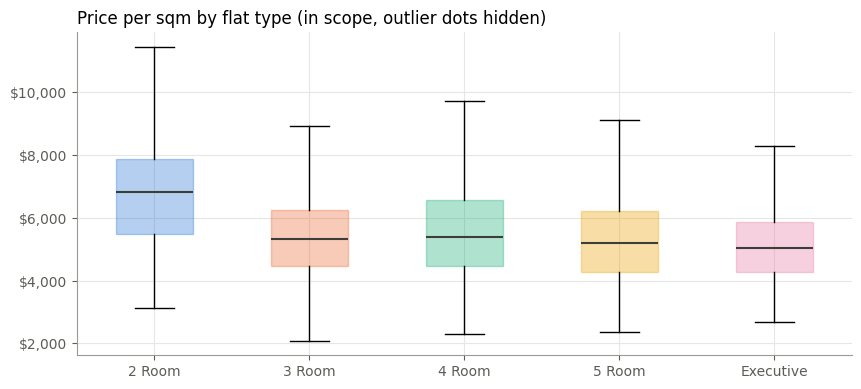

143 flagged outliers
flat_type  flat_model       
3 ROOM     Model A              51
           Premium Apartment    36
5 ROOM     Type S2              22
2 ROOM     Model A              11
5 ROOM     Improved              6
3 ROOM     Terrace               5
1 ROOM     Improved              3
4 ROOM     Type S1               3


,month,town,address,flat_type,flat_model,floor_area_sqm,resale_price,price_psm
202785,2025-08,CENTRAL AREA,1G CANTONMENT RD,5 ROOM,Type S2,105.0,1600000.0,15238.1
149523,2023-12,CENTRAL AREA,1C CANTONMENT RD,4 ROOM,Type S1,93.0,1410888.0,15170.8
202783,2025-07,CENTRAL AREA,1G CANTONMENT RD,5 ROOM,Type S2,105.0,1580000.0,15047.6
202781,2025-06,CENTRAL AREA,1D CANTONMENT RD,5 ROOM,Type S2,105.0,1580000.0,15047.6
149468,2023-08,CENTRAL AREA,1B CANTONMENT RD,4 ROOM,Type S1,94.0,1410000.0,15000.0
122574,2022-10,CENTRAL AREA,1D CANTONMENT RD,4 ROOM,Type S1,93.0,1370000.0,14731.2
175767,2024-11,CENTRAL AREA,1D CANTONMENT RD,5 ROOM,Type S2,105.0,1542880.0,14694.1
175760,2024-10,CENTRAL AREA,1F CANTONMENT RD,5 ROOM,Type S2,107.0,1540000.0,14392.5
175680,2024-05,CENTRAL AREA,1C CANTONMENT RD,5 ROOM,Type S2,106.0,1515000.0,14292.5
211798,2025-09,QUEENSTOWN,53 STRATHMORE AVE,3 ROOM,Premium Apartment,62.0,880888.0,14207.9


In [4]:
fig, ax = plt.subplots()
data = [ins.loc[ins["flat_type"] == t, "price_psm"] for t in TYPES]
bp = ax.boxplot(data, showfliers=False, patch_artist=True, widths=0.5,
                medianprops={"color": "#3d3d3a", "linewidth": 1.5})
ax.set_xticks(range(1, len(TYPES) + 1), [t.title() for t in TYPES])
for patch, t in zip(bp["boxes"], TYPES):
    patch.set_facecolor(COL[t]); patch.set_alpha(0.35); patch.set_edgecolor(COL[t])
ax.set_title("Price per sqm by flat type (in scope, outlier dots hidden)", loc="left")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
plt.show()
out = df[df["psm_outlier"]]
print(f"{len(out)} flagged outliers"); print(out.groupby(["flat_type", "flat_model"]).size().sort_values(ascending=False).head(8).to_string())
out.sort_values("price_psm", ascending=False)[["month", "town", "address", "flat_type", "flat_model", "floor_area_sqm", "resale_price", "price_psm"]].head(10)

**Finding:** _are the outliers real (e.g. Type S = Pinnacle@Duxton, central Premium Apartments) or errors? Decide: keep, cap, or drop for modelling._

## 4 · Remaining lease vs price
Where does value fall away as the lease runs down? Use the **latest 2 years** so price inflation doesn't mix in.

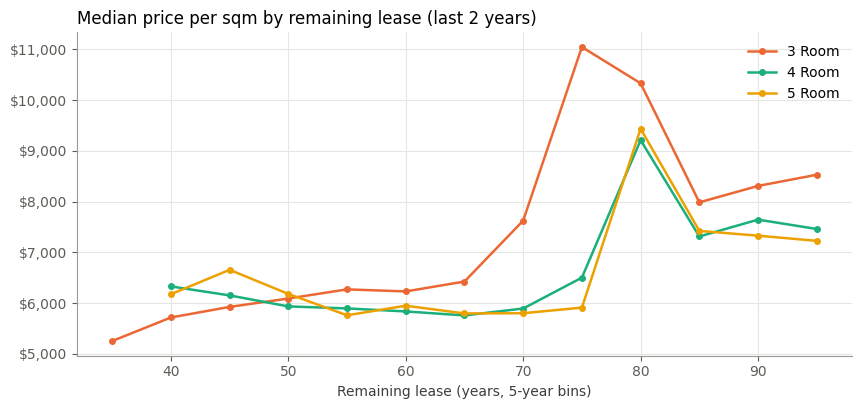

lease_bin
35      59
40     934
45    1801
50    3724
55    6243
60    4246
65    3297
70    5773
75    3245
80    1090
85    5424
90    8667
95     183


In [5]:
recent = ins[ins["year"] >= ins["year"].max() - 1].copy()
recent["lease_bin"] = (recent["remaining_lease_yrs"] // 5 * 5).astype(int)
fig, ax = plt.subplots()
for t in ["3 ROOM", "4 ROOM", "5 ROOM"]:
    s = recent[recent["flat_type"] == t].groupby("lease_bin")["price_psm"].median()
    ax.plot(s.index, s.values, marker="o", markersize=4, color=COL[t], label=t.title())
ax.set_title("Median price per sqm by remaining lease (last 2 years)", loc="left")
ax.set_xlabel("Remaining lease (years, 5-year bins)"); ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
ax.legend(); plt.show()
print(recent.groupby("lease_bin").size().to_string())

**Finding:** _shape of the lease curve; is there a cliff (e.g. below 60 years, where CPF/loan rules tighten)? This checks the lease bands in config.py._

_Careful: raw curves mix location into the lease effect. A bump at 75–80 years, for example, is more likely newer central flats (DBSS, Premium Apartments) than lease itself. Separating these is the hedonic model's job, so treat these curves as descriptive only. The same applies to the storey chart: very high floors are mostly central blocks._

## 5 · Storey premium
Price per sqm for each storey band, relative to the lowest band (floors 1–6), last 2 years.

storey_band  1-6  7-12   13+
flat_type                   
2 ROOM       0.0   4.1   9.6
3 ROOM       0.0   3.9  32.1
4 ROOM       0.0   7.1  27.9
5 ROOM       0.0   6.5  21.4
EXECUTIVE    0.0   3.9   5.2


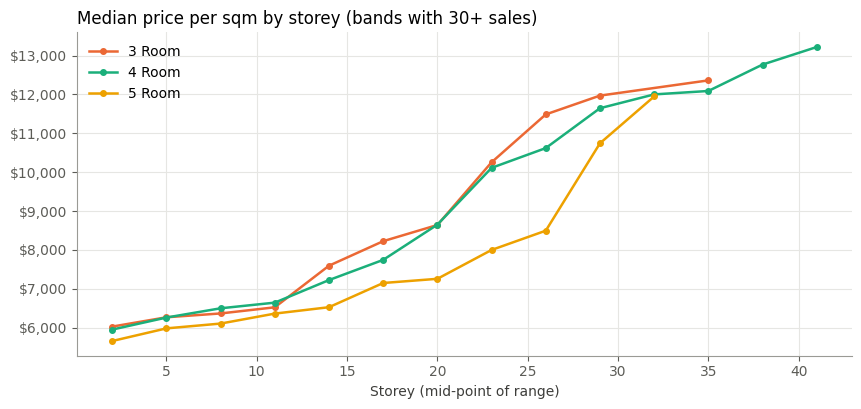

In [6]:
recent["storey_band"] = band(recent["storey_mid"], C.STOREY_BANDS)
prem = recent.groupby(["flat_type", "storey_band"], observed=True)["price_psm"].median().unstack()
print((prem.div(prem[C.STOREY_BANDS[0][2]], axis=0) * 100 - 100).round(1).loc[TYPES].to_string())   # % premium over floors 1-6
fig, ax = plt.subplots()
for t in ["3 ROOM", "4 ROOM", "5 ROOM"]:
    s = recent[recent["flat_type"] == t].groupby("storey_mid")["price_psm"].median()
    s = s[recent[recent["flat_type"] == t].groupby("storey_mid").size() >= 30]
    ax.plot(s.index, s.values, marker="o", markersize=4, color=COL[t], label=t.title())
ax.set_title("Median price per sqm by storey (bands with 30+ sales)", loc="left"); ax.set_xlabel("Storey (mid-point of range)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}")); ax.legend(); plt.show()

**Finding:** _size of the storey premium; is it linear, or does it jump at high floors? Do the 1–6 / 7–12 / 13+ bands make sense?_

## 6 · Flat models and sizes

In [7]:
fm = ins.groupby("flat_model_group").agg(sales=("resale_price", "size"), median_psm=("price_psm", "median"),
                                         median_area=("floor_area_sqm", "median")).sort_values("sales", ascending=False)
print(fm.round(0).to_string())
print(); print(ins.groupby("flat_type")["floor_area_sqm"].describe()[["min", "25%", "50%", "75%", "max"]].loc[TYPES].to_string())

                   sales  median_psm  median_area
flat_model_group                                 
Model A            89915      5532.0         93.0
Improved           58894      5163.0        112.0
New Generation     29282      4939.0         73.0
Premium Apartment  26566      5505.0         97.0
Simplified          9222      5214.0         84.0
Apartment           8632      4950.0        144.0
Maisonette          7072      5320.0        146.0
Standard            6398      5306.0         63.0
DBSS                3823      8249.0         94.0
Type S               590     10762.0         95.0
2-room               513      8138.0         47.0
Adjoined             416      5339.0        139.0
Multi-generation      84      6367.0        120.0

             min    25%    50%    75%    max
flat_type                                   
2 ROOM      34.0   45.0   47.0   47.0   67.0
3 ROOM      51.0   65.0   67.0   70.0  137.0
4 ROOM      70.0   91.0   93.0  101.0  176.0
5 ROOM      99.0  112.0 

**Finding:** _which model families matter; any size oddities within a flat type._

## 7 · Towns
Median price per sqm by town, last 12 complete months.

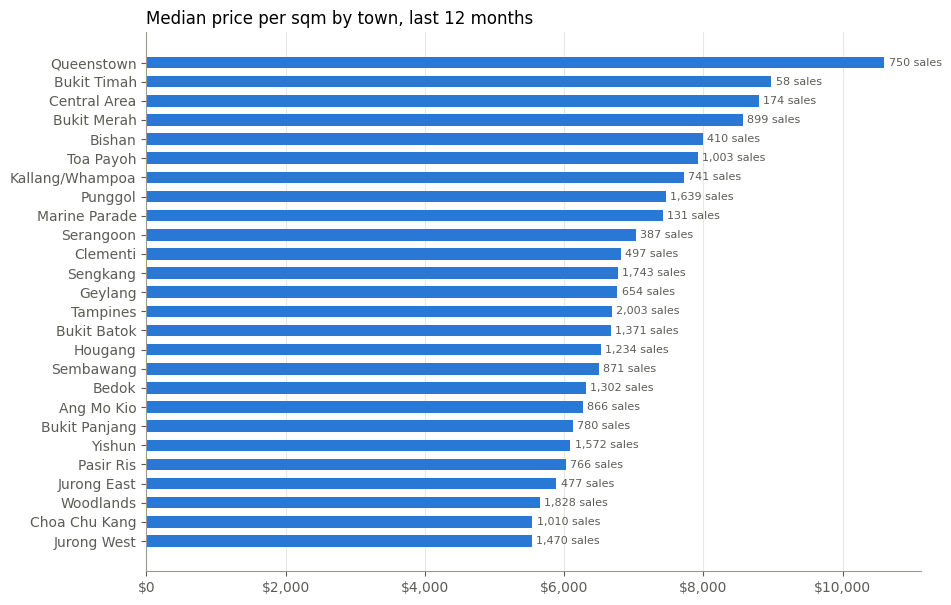

In [8]:
last12 = sorted(ins["month"].unique())[-12:]
tw = ins[ins["month"].isin(last12)].groupby("town").agg(median_psm=("price_psm", "median"), sales=("price_psm", "size"))
tw = tw.sort_values("median_psm")
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(tw.index.str.title(), tw["median_psm"], color="#2a78d6", height=0.6)
ax.set_title("Median price per sqm by town, last 12 months", loc="left"); ax.grid(axis="y", visible=False)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"${v:,.0f}"))
for y, (v, n) in enumerate(zip(tw["median_psm"], tw["sales"])):
    ax.text(v + 60, y, f"{n:,} sales", va="center", fontsize=8, color="#5c5c57")
plt.show()

**Finding:** _spread between cheapest and dearest towns; towns with thin volume._

## 8 · Data quirks summary

In [9]:
flags = {f: int(df[f].sum()) for f in ["is_exact_dup", "lease_mismatch", "psm_outlier", "partial_month"]}
flags["out of scope (1-room / multi-gen / Terrace)"] = int((~df["in_scope"] & ~df["partial_month"]).sum())
pd.Series(flags, name="rows").to_frame()

,rows
is_exact_dup,635
lease_mismatch,1
psm_outlier,143
partial_month,212
out of scope (1-room / multi-gen / Terrace),301


**Finding:** _decisions taken for each flag, and why (for the Data Preparation section)._

## 9 · Profile sparsity (without MRT band)
Profiles = town × flat type × lease band × MRT band × storey band. MRT band needs coordinates, so here we check the other four.
If many cells have under 5 sales a year **before** splitting by MRT distance, the bands are too fine. Raise this before the 9 Oct check-in.

In [10]:
r12 = ins[ins["month"].isin(last12)].copy()
r12["lease_band"] = band(r12["remaining_lease_yrs"], C.LEASE_BANDS)
r12["storey_band"] = band(r12["storey_mid"], C.STOREY_BANDS)
cells = r12.groupby(["town", "flat_type", "lease_band", "storey_band"], observed=True).size()
print(f"{len(cells):,} cells with any sales in the last 12 months")
for k in [1, 5, 10, 20]:
    print(f"  {(cells >= k).mean():6.1%} of cells have {k}+ sales  (covering {cells[cells >= k].sum() / cells.sum():.1%} of sales)")
print("\nThinnest towns (median sales per cell):"); print(cells.groupby("town").median().sort_values().head(8).to_string())

731 cells with any sales in the last 12 months
  100.0% of cells have 1+ sales  (covering 100.0% of sales)
   80.7% of cells have 5+ sales  (covering 98.7% of sales)
   66.6% of cells have 10+ sales  (covering 95.8% of sales)
   47.1% of cells have 20+ sales  (covering 87.5% of sales)

Thinnest towns (median sales per cell):
town
CENTRAL AREA      3.5
BUKIT TIMAH       4.0
QUEENSTOWN        7.0
CLEMENTI          7.0
JURONG EAST       8.0
BISHAN            8.0
PASIR RIS         8.0
MARINE PARADE    10.5


**Finding:** _share of thin cells; options if too many (merge lease bands, drop storey band for thin towns, or pool towns into regions)._